In [7]:
from sklearn.datasets import fetch_california_housing 
import pandas as pd 
import numpy as np 

housing = fetch_california_housing()

print(type(housing))
print(dir(housing))


<class 'sklearn.utils._bunch.Bunch'>
['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']


In [8]:

df = pd.DataFrame(housing.data,columns = housing.feature_names)
df["Price"] = housing.target
df.head()
print(df.shape)
df.describe()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


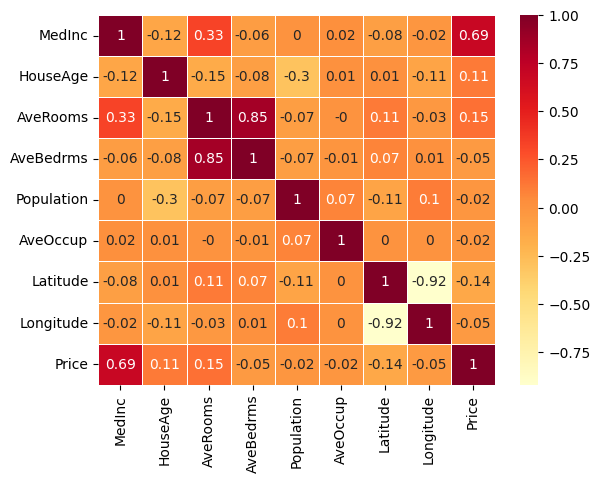

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation = df.corr().round(2)

sns.heatmap(
    correlation,
    annot= True,       # True — show numbers
    fmt='g',         # 'g' — whole numbers
    cmap='YlOrRd',        # 'YlOrRd' — yellow=low, red=high
    linewidths=0.5,
    linecolor='white'
)

plt.show()


In [10]:
from sklearn.linear_model import LinearRegression

reshaped_medinc = df['MedInc'].values.reshape(-1,1)

model = LinearRegression()
model.fit(X=reshaped_medinc, y= df['Price'])

print(model.coef_)
print(model.intercept_)




[0.41793849]
0.4508557670326787


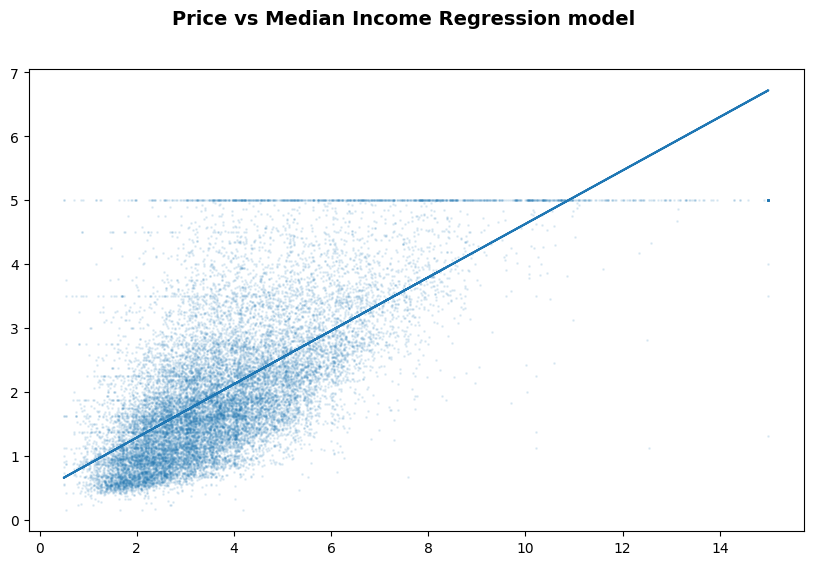

In [18]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
fig.suptitle('Price vs Median Income Regression model', fontsize=14, fontweight='bold')

plt.scatter(
        reshaped_medinc,
        df['Price'],
        alpha=0.1,
        s=1
    )

predictions = model.predict(reshaped_medinc)

plt.plot(reshaped_medinc,predictions)

plt.show()


# Correlation & Regression Analysis
## California Housing Dataset | 20,640 rows

---

## What I Built
A statistical analysis project to identify which features correlate with house prices in California, and a linear regression model to predict prices from median income.

---

## Correlation Analysis

Correlation measures how strongly two variables are related, on a scale of -1 to 1.
- `1` = perfect positive relationship
- `-1` = perfect negative relationship
- `0` = no relationship

### Key Findings from Heatmap

| Feature | Correlation with Price |
|---|---|
| MedInc | **0.69** ✅ strongest |
| AveRooms | 0.15 |
| HouseAge | 0.11 |
| Population | -0.02 |
| Latitude | -0.14 |

**MedInc (median income) is the strongest predictor of house price at 0.69** — richer neighbourhoods consistently have higher prices. Population, which intuitively seems important, has almost zero correlation (-0.02).

Notable: Latitude and Longitude have -0.92 correlation with each other — a geometric artifact of California's diagonal coastline.

---

## Linear Regression

Regression draws the best fit line through the data to enable prediction.

**Equation:** `Price = 0.418 × MedInc + 0.451`

| Parameter | Value | Meaning |
|---|---|---|
| Coefficient (slope) | 0.418 | Every 1 unit increase in MedInc → Price increases by 0.418 |
| Intercept | 0.451 | Predicted price when MedInc = 0 |

**Example prediction:** MedInc = 5 → Price = (0.418 × 5) + 0.451 = **2.54**

---

## Key Observations from the Chart

- The regression line fits the general trend well
- Wide scatter around the line — MedInc alone doesn't explain everything
- Visible data cap at Price = 5.0 — the dataset capped house prices at $500K, creating an artificial horizontal band in the data

---

## Limitations & Next Steps

This model uses only one feature (MedInc). A stronger model would use all 8 features — this is called **multiple linear regression**. Adding AveRooms, Latitude, and HouseAge would likely improve prediction accuracy significantly.
